# 🎯 Microgrid Project: Final Visualizations for Research Paper & PPT
This notebook loads all 4 trained models (`CNN-LSTM`, `GRU`, `LSTM`, `XGBoost`), runs them against the test dataset, and generates clean, professional plots mapped back to **Real Physical Values (MegaWatts)**.

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Setting up global layout styles for professional paper-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 2
})

# Ensure we're in the final_year_rev4 directory
if os.path.basename(os.getcwd()) != "final_year_rev4":
    for _ in range(3): # Navigate up if deep, or change if parallel
        if os.path.exists("datasets/unified_microgrid_24h_results.csv"): break
        elif os.path.exists("final_year_rev4"): os.chdir("final_year_rev4"); break
        else: os.chdir("..")

print("Visualizing inside:", os.getcwd())

Visualizing inside: /home/amarjithtk/acoder/finalyear-project-rev2/final_year_rev4


In [14]:
# --- 1. LOAD DATA & SCALER ---
DATA_FILE = "datasets/unified_microgrid_24h_results.csv"
SEQ_LENGTH = 24

df = pd.read_csv(DATA_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(by='Timestamp').reset_index(drop=True)
timestamps = df['Timestamp'].values

features = ['Hour', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_ms', 'Cloud_Cover_pct', 'Solar_Irradiance_Wm2']
targets = ['Solar_MW', 'Wind_MW', 'Residential_Load_MW', 'Commercial_Load_MW', 'Industrial_Load_MW', 'Critical_Load_MW']

data = df[features + targets].values
scaler = joblib.load("models/scaler.joblib")
scaled_data = scaler.transform(data)

# Create identical Test Set sequences (80/20)
X, y = [], []
for i in range(len(scaled_data) - SEQ_LENGTH):
    X.append(scaled_data[i:i + SEQ_LENGTH, :])
    y.append(scaled_data[i + SEQ_LENGTH, -len(targets):])

X = np.array(X)
y = np.array(y)

train_size = int(len(X) * 0.8)
X_test = X[train_size:]
y_test = y[train_size:]
test_timestamps = timestamps[train_size + SEQ_LENGTH:]

In [15]:
# --- 2. LOAD MODELS ARCHITECTURE & WEIGHTS ---
input_size = len(features) + len(targets)
output_size = len(targets)

class MicrogridCNNLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1d = nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1, batch_first=True)
        self.fc = nn.Linear(64, output_size)
    def forward(self, x):
        x = x.permute(0, 2, 1)
        c_out = self.relu(self.conv1d(x))
        c_out = c_out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(c_out)
        return self.fc(lstm_out[:, -1, :])

class MicrogridLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 64, 2, batch_first=True)
        self.fc = nn.Linear(64, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class MicrogridGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(input_size, 64, 2, batch_first=True)
        self.fc = nn.Linear(64, output_size)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

m_cnn_lstm = MicrogridCNNLSTM(); m_cnn_lstm.load_state_dict(torch.load("models/cnn_lstm_model.pth")); m_cnn_lstm.eval()
m_lstm = MicrogridLSTM(); m_lstm.load_state_dict(torch.load("models/lstm_model.pth")); m_lstm.eval()
m_gru = MicrogridGRU(); m_gru.load_state_dict(torch.load("models/gru_model.pth")); m_gru.eval()
m_xgb = joblib.load("models/xgboost_model.joblib")

In [16]:
# --- 3. RUN INFERENCE & INVERSE SCALE (Convert to MW) ---
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test)
    raw_cnn = m_cnn_lstm(X_test_t).numpy()
    raw_lstm = m_lstm(X_test_t).numpy()
    raw_gru = m_gru(X_test_t).numpy()

raw_xgb = m_xgb.predict(np.array([seq.flatten() for seq in X_test]))

def to_mw(preds):
    """Maps normalized 0-1 values back into physical MW values"""
    dummy = np.zeros((preds.shape[0], input_size))
    dummy[:, -output_size:] = preds
    return scaler.inverse_transform(dummy)[:, -output_size:]

y_test_mw = to_mw(y_test)
preds = {
    'CNN-LSTM': to_mw(raw_cnn),
    'XGBoost': to_mw(raw_xgb),
    'GRU': to_mw(raw_gru),
    'LSTM': to_mw(raw_lstm)
}

/tmp/ipykernel_42296/1129322010.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x='Model', y='MAE (MW)', palette='Blues_d', ax=axes[0])
/tmp/ipykernel_42296/1129322010.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x='Model', y='RMSE (MW)', palette='Reds_d', ax=axes[1])
/tmp/ipykernel_42296/1129322010.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metrics, x='Model', y='MAPE (%)', palette='Greens_d', ax=axes[2])


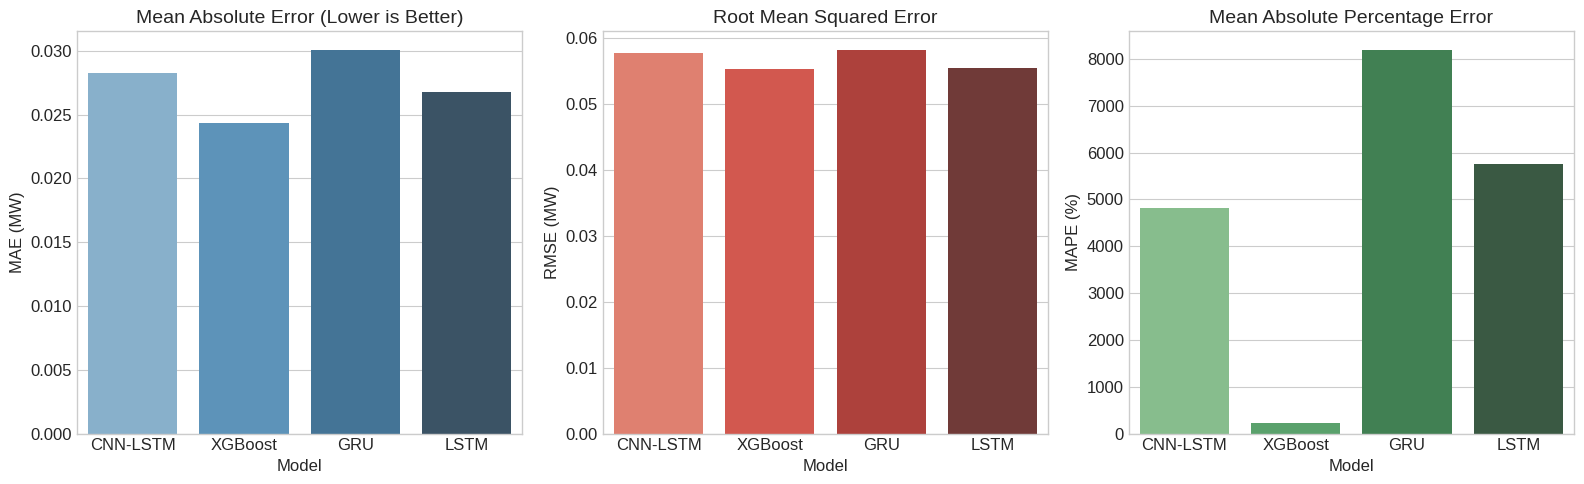

,MAE (MW),RMSE (MW),MAPE (%)
Model,,,
CNN-LSTM,0.028219,0.057706,4816.482417
XGBoost,0.024353,0.055326,229.289944
GRU,0.030018,0.058110,8178.097431
LSTM,0.026769,0.055499,5765.362704


In [17]:
# === PLOT 1: MODEL COMPARISON BAR CHART ===
# Calculates Overall MAE and RMSE in actual MegaWatts (MW)
metrics_table = []
for name, p in preds.items():
    mae = mean_absolute_error(y_test_mw, p)
    rmse = np.sqrt(mean_squared_error(y_test_mw, p))
    # Ignore zero values for MAPE stability
    mape = np.mean(np.abs((y_test_mw - p) / np.maximum(y_test_mw, 1e-5))) * 100 
    metrics_table.append({"Model": name, "MAE (MW)": mae, "RMSE (MW)": rmse, "MAPE (%)": mape})

df_metrics = pd.DataFrame(metrics_table)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.barplot(data=df_metrics, x='Model', y='MAE (MW)', palette='Blues_d', ax=axes[0])
axes[0].set_title('Mean Absolute Error (Lower is Better)')

sns.barplot(data=df_metrics, x='Model', y='RMSE (MW)', palette='Reds_d', ax=axes[1])
axes[1].set_title('Root Mean Squared Error')

sns.barplot(data=df_metrics, x='Model', y='MAPE (%)', palette='Greens_d', ax=axes[2])
axes[2].set_title('Mean Absolute Percentage Error')

plt.tight_layout()
plt.show()
df_metrics.set_index('Model') # Show the raw table

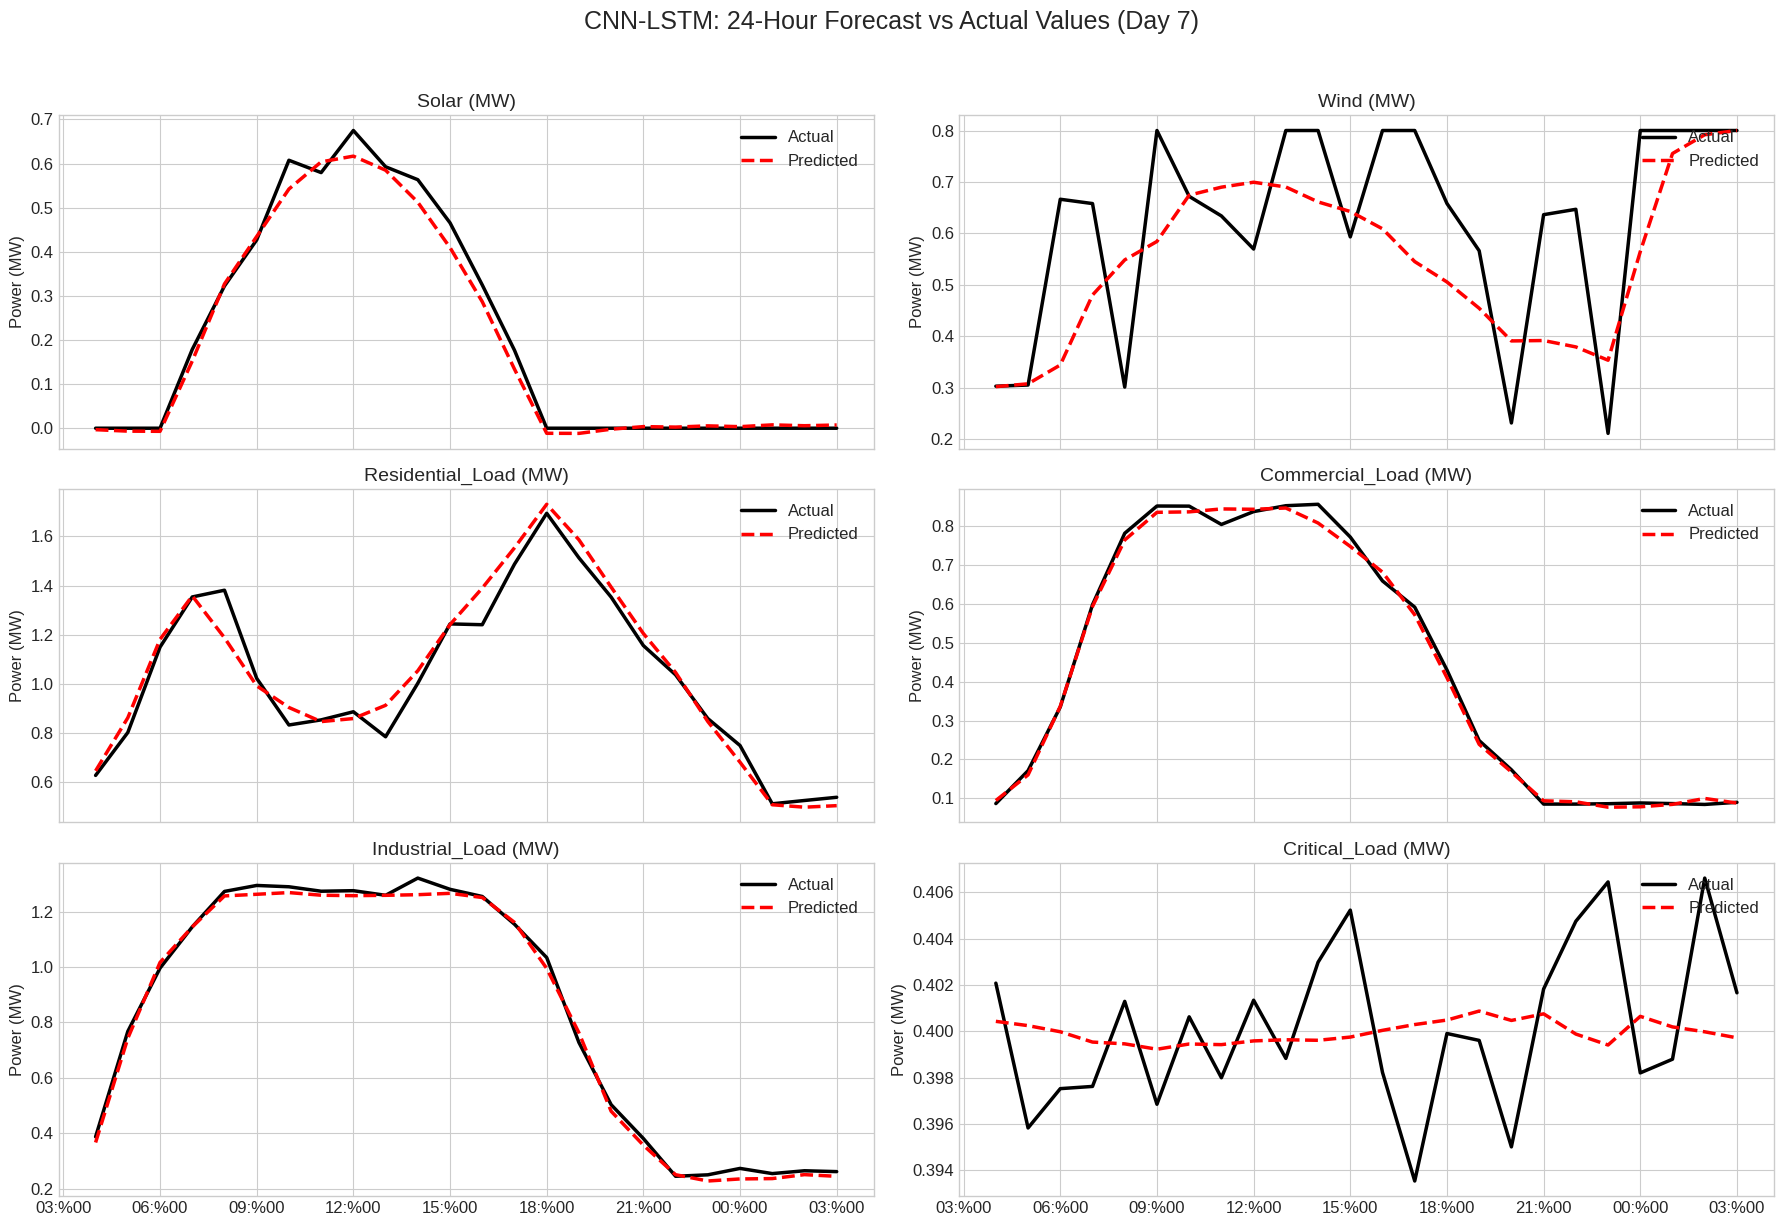

In [18]:
# === PLOT 2: ACTUAL VS PREDICTED (DAY 7 ZOOM IN) ===
# We pull exactly 24 hours of data from the test set for visual clarity
BEST_MODEL = "CNN-LSTM"
START_IDX = 24 * 6  # Start of 7th Day
END_IDX = START_IDX + 24
time_slice = test_timestamps[START_IDX:END_IDX]

fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex=True)
fig.suptitle(f"{BEST_MODEL}: 24-Hour Forecast vs Actual Values (Day 7)", fontsize=18, y=1.02)
axes = axes.flatten()

for i, tar in enumerate(targets):
    axes[i].plot(time_slice, y_test_mw[START_IDX:END_IDX, i], 'k-', label='Actual', linewidth=2.5)
    axes[i].plot(time_slice, preds[BEST_MODEL][START_IDX:END_IDX, i], 'r--', label='Predicted', linewidth=2.5)
    axes[i].set_title(tar.replace('_MW', ' (MW)'))
    axes[i].legend(loc="upper right")
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%H:%00'))
    axes[i].set_ylabel("Power (MW)")

plt.tight_layout()
plt.show()

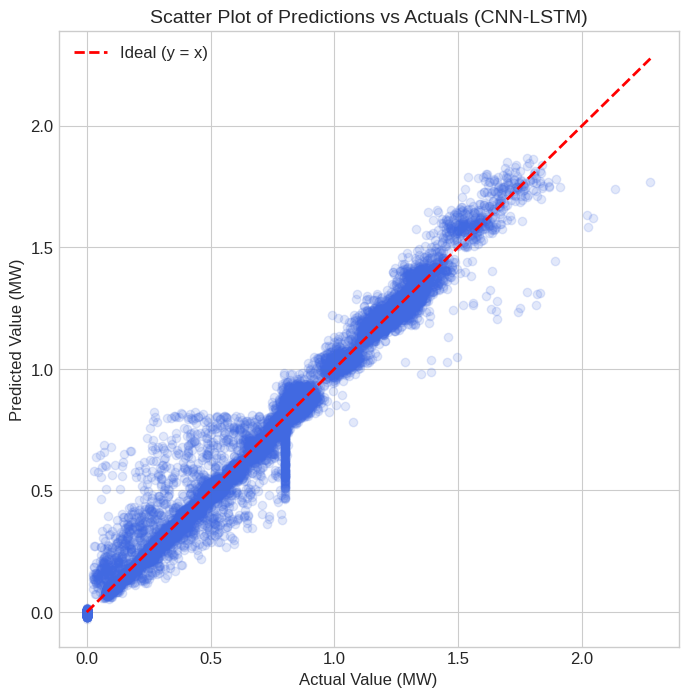

In [19]:
# === PLOT 3: SCATTER PLOT ===
# Highlights R^2 correlation and adherence to y=x ideal line

y_true_flat = y_test_mw.flatten()
y_pred_flat = preds[BEST_MODEL].flatten()

plt.figure(figsize=(8, 8))
plt.scatter(y_true_flat, y_pred_flat, alpha=0.15, color='royalblue')
plt.plot([y_true_flat.min(), y_true_flat.max()], [y_true_flat.min(), y_true_flat.max()], 'r--', lw=2, label="Ideal (y = x)")
plt.xlabel("Actual Value (MW)")
plt.ylabel("Predicted Value (MW)")
plt.title(f"Scatter Plot of Predictions vs Actuals ({BEST_MODEL})")
plt.legend()
plt.show()

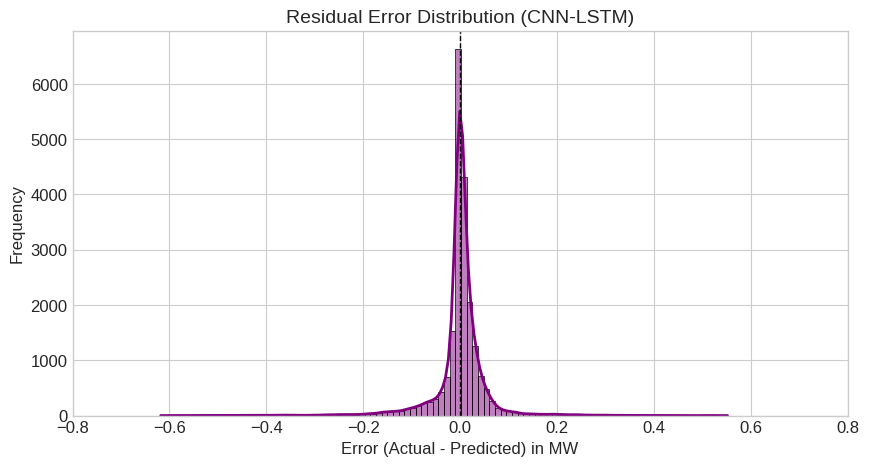

In [20]:
# === PLOT 4: ERROR DISTRIBUTION (HISTOGRAM) ===
residuals = y_true_flat - y_pred_flat

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=100, kde=True, color='purple', alpha=0.5)
plt.title(f"Residual Error Distribution ({BEST_MODEL})")
plt.xlabel("Error (Actual - Predicted) in MW")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--', lw=1)
plt.xlim([-0.8, 0.8])
plt.show()

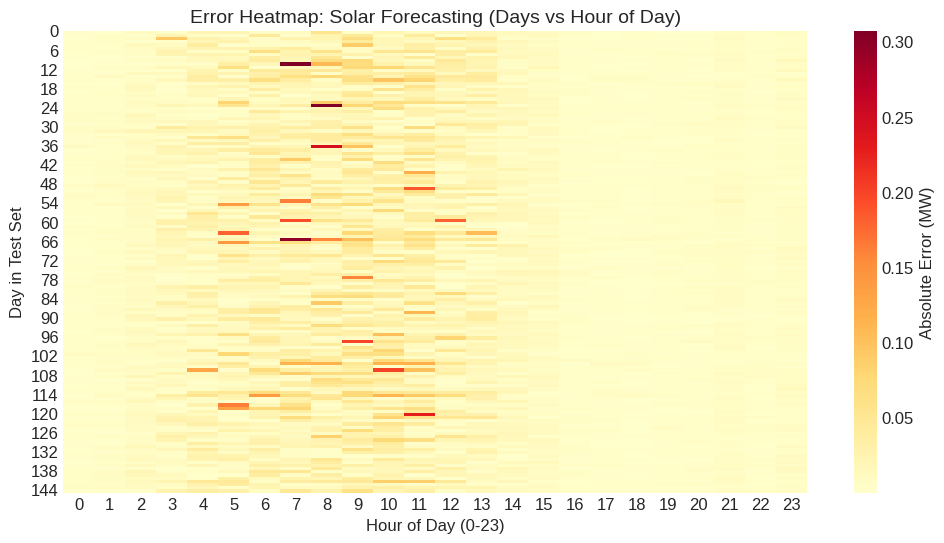

In [21]:
# === PLOT 5: ERROR HEATMAP (When does it fail?) ===
# Reshaping tracking errors by Hour of Day to find consistent blind spots
total_days = len(y_pred_flat) // (len(targets) * 24)
# Let's map Absolute Error just for Solar MW (index 0)
solar_actual = y_test_mw[:total_days*24, 0].reshape(total_days, 24)
solar_pred = preds[BEST_MODEL][:total_days*24, 0].reshape(total_days, 24)
solar_error = np.abs(solar_actual - solar_pred)

plt.figure(figsize=(12, 6))
sns.heatmap(solar_error, cmap="YlOrRd", cbar_kws={'label': 'Absolute Error (MW)'})
plt.title("Error Heatmap: Solar Forecasting (Days vs Hour of Day)")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Day in Test Set")
plt.show()

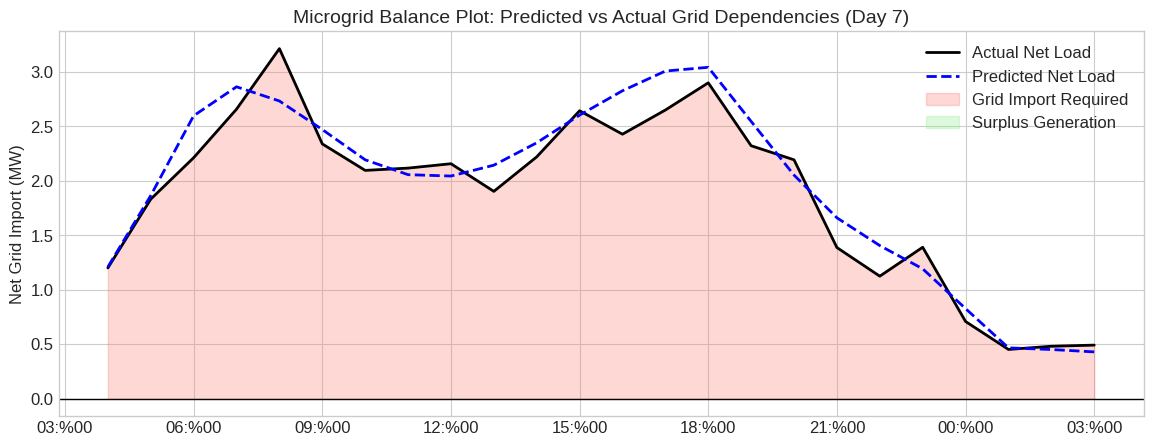

In [22]:
# === PLOT 6: SYSTEM-LEVEL GRID BALANCE (Very Important) ===
# Net Load = Total Loads - (Solar + Wind)
# Shows when grid requires battery/import (Red) vs when it has surplus (Green)

total_load_actual = np.sum(y_test_mw[:, 2:], axis=1)   # Sum of the 4 loads
total_load_pred   = np.sum(preds[BEST_MODEL][:, 2:], axis=1)

total_der_actual = np.sum(y_test_mw[:, :2], axis=1)    # Solar + Wind
total_der_pred   = np.sum(preds[BEST_MODEL][:, :2], axis=1)

net_load_act = total_load_actual - total_der_actual
net_load_pred = total_load_pred - total_der_pred

plt.figure(figsize=(14, 5))
plt.plot(time_slice, net_load_act[START_IDX:END_IDX], 'k-', label='Actual Net Load', lw=2)
plt.plot(time_slice, net_load_pred[START_IDX:END_IDX], 'b--', label='Predicted Net Load', lw=2)

plt.axhline(0, color='black', lw=1)
plt.fill_between(time_slice, 0, net_load_act[START_IDX:END_IDX], where=(net_load_act[START_IDX:END_IDX] > 0), color='salmon', alpha=0.3, label='Grid Import Required')
plt.fill_between(time_slice, 0, net_load_act[START_IDX:END_IDX], where=(net_load_act[START_IDX:END_IDX] < 0), color='lightgreen', alpha=0.3, label='Surplus Generation')

plt.title("Microgrid Balance Plot: Predicted vs Actual Grid Dependencies (Day 7)")
plt.ylabel("Net Grid Import (MW)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%00'))
plt.legend()
plt.show()

In [23]:
# === EXPORT DAY 7 RESULTS TO CSV ===
# Save the 24-hour actual vs predicted data for the proposed model 
# to a CSV file for easy inspection or tabular presentation in the paper.

import os
os.makedirs("proposed_model_results", exist_ok=True)

export_data = {
    "Timestamp": time_slice
}
predicted_only_data = {
    "Timestamp": time_slice
}

for i, tar in enumerate(targets):
    export_data[f"Actual_{tar}"] = y_test_mw[START_IDX:END_IDX, i]
    export_data[f"Predicted_{tar}"] = preds[BEST_MODEL][START_IDX:END_IDX, i]
    predicted_only_data[tar] = preds[BEST_MODEL][START_IDX:END_IDX, i]

export_data["Actual_Net_Load_MW"] = net_load_act[START_IDX:END_IDX]
export_data["Predicted_Net_Load_MW"] = net_load_pred[START_IDX:END_IDX]

df_day7 = pd.DataFrame(export_data)
df_pred = pd.DataFrame(predicted_only_data)

csv_filename_1 = "proposed_model_results/proposed_model_day7_results.csv"
csv_filename_2 = "proposed_model_results/predicted_results.csv"

df_day7.to_csv(csv_filename_1, index=False)
df_pred.to_csv(csv_filename_2, index=False)

print(f"✅ Successfully saved Day 7 detailed results to {csv_filename_1}")
print(f"✅ Successfully saved straight-forward predictions to {csv_filename_2}")
display(df_pred.head())

✅ Successfully saved Day 7 detailed results to proposed_model_results/proposed_model_day7_results.csv
✅ Successfully saved straight-forward predictions to proposed_model_results/predicted_results.csv


,Timestamp,Solar_MW,Wind_MW,Residential_Load_MW,Commercial_Load_MW,Industrial_Load_MW,Critical_Load_MW
0,2020-08-13 04:00:00,-0.003308,0.301874,0.646476,0.094133,0.366687,0.400436
1,2020-08-13 05:00:00,-0.006627,0.307460,0.862424,0.160202,0.743157,0.400251
2,2020-08-13 06:00:00,-0.007046,0.344025,1.181544,0.336706,1.016810,0.399986
3,2020-08-13 07:00:00,0.152369,0.480113,1.358264,0.593877,1.145239,0.399541
4,2020-08-13 08:00:00,0.327120,0.548386,1.187901,0.765091,1.257037,0.399464
